In [26]:
import torch
import sys
sys.path.append('..')
from models import TrainableModelBase
from dataclasses import dataclass
from torch import nn
from utils import *
from typing import Literal

class SimpleLinear(TrainableModelBase):
    @dataclass
    class ModelConfig(TrainableModelBase.ModelConfig):
        latent_dim: int = 64

    def __init__(
        self,
        user_matrix: torch.Tensor,
        item_matrix: torch.Tensor,
        rate_matrix: torch.Tensor,
        model_config: ModelConfig,
        loss_config: TrainableModelBase.LossConfig,
    ):
        super().__init__(model_config=model_config, loss_config=loss_config)
        device = torch.device(self.model_config.device)
        self.rate_matrix = rate_matrix.to(device)
        self.user_matrix = user_matrix.to(device)
        self.item_matrix = item_matrix.to(device)

        self.user_FS = nn.Linear(user_matrix.shape[1], self.model_config.latent_dim, bias=False).to(device)
        self.item_FS = nn.Linear(item_matrix.shape[1], self.model_config.latent_dim, bias=False).to(device)
    
    def forward(self, user_index: torch.Tensor, item_index: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        user_embeddings = self.user_FS(self.user_matrix[user_index])
        item_embeddings = self.item_FS(self.item_matrix[item_index])
        return user_embeddings, item_embeddings

    @torch.no_grad()
    def predict(self) -> torch.Tensor:
        user_embeddings = self.user_FS(self.user_matrix)
        item_embeddings = self.item_FS(self.item_matrix)
        return user_embeddings @ item_embeddings.T


In [27]:
import matplotlib.pyplot as plt


def plot_metrics_by_set(
    test_result_list: list[dict],
    num_sets: int,
    position: Literal["upper left", "upper right", "lower left", "lower right"] = "lower right",
) -> None:
    if not test_result_list:
        return

    first_result = test_result_list[0]
    if not isinstance(first_result, dict):
        raise TypeError("Each test result should be a dict containing metric values.")

    # Keep numeric metrics only and plot the first four.
    metric_names = [
        key
        for key, value in first_result.items()
        if isinstance(value, (int, float))
    ][:4]

    if len(metric_names) < 4:
        raise ValueError("At least 4 numeric metrics are required for plotting.")

    x = list(range(1, num_sets + 1))

    plt.figure(figsize=(5, 5))
    for metric_name in metric_names:
        y = [result[metric_name] for result in test_result_list]
        plt.plot(x, y, linewidth=2, label=metric_name)

    # Show at most 10 x-axis ticks while preserving all plotted points.
    tick_step = max(1, num_sets // 10)
    tick_positions = list(range(tick_step, num_sets + 1, tick_step))

    plt.xlabel("Set Index")
    plt.ylabel("Metric Value")
    plt.ylim(0.0, 0.25)
    plt.xticks(tick_positions)
    plt.grid(alpha=0.25)
    plt.legend(loc=position)
    plt.tight_layout()
    plt.show()


def cf_cumulative(
    num_sets: int = 10,
    interaction_data: str = "games",
):
    datahandler = DataHandler(
        interaction_data=interaction_data,
        batch_size=64,
        num_neg_item=1,
    )
    (U, S, V_T) = torch.linalg.svd(datahandler.rate_matrix, full_matrices=False)
    V = V_T.T
    user_index_tuple = torch.chunk(torch.arange(U.shape[1]), num_sets)
    item_index_tuple = torch.chunk(torch.arange(V.shape[1]), num_sets)
    user_cumulative_index_list = []
    for i in range(len(user_index_tuple)):
        user_cumulative_index_list.append(torch.cat(user_index_tuple[: i + 1]))
    item_cumulative_index_list = []
    for i in range(len(item_index_tuple)):
        item_cumulative_index_list.append(torch.cat(item_index_tuple[: i + 1]))

    
    metric = Metric(device="cuda")
    test_result_list = []

    for i in range(num_sets):
        user_idx = user_cumulative_index_list[i]
        item_idx = item_cumulative_index_list[i]
        # Truncated SVD factors with sqrt singular values split to both sides.
        user_cf_matrix = U[:, user_idx]
        item_cf_matrix = V[:, item_idx]

        model = SimpleLinear(
            user_matrix=user_cf_matrix,
            item_matrix=item_cf_matrix,
            rate_matrix=datahandler.rate_matrix,
            model_config=SimpleLinear.ModelConfig(latent_dim=256, device="cuda"),
            loss_config=TrainableModelBase.BPRLossConfig(
                similarity="dot",
                num_neg_item=1,
            ),
        )
        test_result = train_model(
            datahandler=datahandler,
            num_epochs=20,
            metric=metric,
            model=model,
        )
        test_result_list.append(test_result)

    plot_metrics_by_set(test_result_list=test_result_list, num_sets=num_sets, position="upper right")

def se_cumulative(
    num_sets: int = 20,
    interaction_data: Literal["games"] = "games",
    semantic_data: str = "games",
):
    datahandler = DataHandler(
        interaction_data=interaction_data,
        semantic_data=semantic_data,
        batch_size=4096,
        num_workers=32,
        num_neg_item=1,
    )
    (U_user, S_user, V_user_T) = torch.linalg.svd(datahandler.user_semantic_embeddings, full_matrices=False)
    (U_item, S_item, V_item_T) = torch.linalg.svd(datahandler.item_semantic_embeddings, full_matrices=False)

    user_index_tuple = torch.chunk(torch.arange(U_user.shape[1]), num_sets)
    item_index_tuple = torch.chunk(torch.arange(U_item.shape[1]), num_sets)
    user_cumulative_index_list = []
    for i in range(len(user_index_tuple)):
        user_cumulative_index_list.append(torch.cat(user_index_tuple[: i + 1]))
    item_cumulative_index_list = []
    for i in range(len(item_index_tuple)):
        item_cumulative_index_list.append(torch.cat(item_index_tuple[: i + 1]))

    
    metric = Metric(device="cuda")
    test_result_list = []

    for i in range(num_sets):
        model = SimpleLinear(
            user_matrix=U_user[:, user_cumulative_index_list[i]] @ V_user_T[user_cumulative_index_list[i], :],
            item_matrix=U_item[:, item_cumulative_index_list[i]] @ V_item_T[item_cumulative_index_list[i], :],
            rate_matrix=datahandler.rate_matrix,
            model_config=SimpleLinear.ModelConfig(latent_dim=256, device="cuda"),
            loss_config=TrainableModelBase.BPRLossConfig(
                similarity="dot",
                num_neg_item=1,
            ),
        )
        test_result = train_model(
            datahandler=datahandler,
            num_epochs=200,
            metric=metric,
            model=model,
        )
        test_result_list.append(test_result)

    plot_metrics_by_set(test_result_list=test_result_list, num_sets=num_sets, position="lower right")

Initial Model Performance (Before Training):
  Recall@10: 0.0208, NDCG@10: 0.0095, Recall@20: 0.0381, NDCG@20: 0.0141
Epoch [    1/20]  Loss: 0.6307  Time: 3.0s Data:0.2s ZG:0.1s Loss:0.8s BW:1.2s Step:0.7s Eval:0.0s Other:0.1s  Recall@10: 0.1212, NDCG@10: 0.0648, Recall@20: 0.1775, NDCG@20: 0.0800
Epoch [    2/20]  Loss: 0.4380  Time: 3.0s Data:0.2s ZG:0.1s Loss:0.8s BW:1.1s Step:0.7s Eval:0.0s Other:0.1s  Recall@10: 0.1300, NDCG@10: 0.0704, Recall@20: 0.1906, NDCG@20: 0.0866
Epoch [    3/20]  Loss: 0.3265  Time: 3.0s Data:0.2s ZG:0.1s Loss:0.8s BW:1.1s Step:0.7s Eval:0.0s Other:0.1s  Recall@10: 0.1316, NDCG@10: 0.0712, Recall@20: 0.1918, NDCG@20: 0.0871
Epoch [    4/20]  Loss: 0.2723  Time: 3.0s Data:0.2s ZG:0.1s Loss:0.8s BW:1.1s Step:0.7s Eval:0.0s Other:0.1s  Recall@10: 0.1282, NDCG@10: 0.0688, Recall@20: 0.1912, NDCG@20: 0.0856
Epoch [    5/20]  Loss: 0.2406  Time: 3.0s Data:0.2s ZG:0.1s Loss:0.8s BW:1.2s Step:0.7s Eval:0.0s Other:0.1s  Recall@10: 0.1227, NDCG@10: 0.0663, Recall@

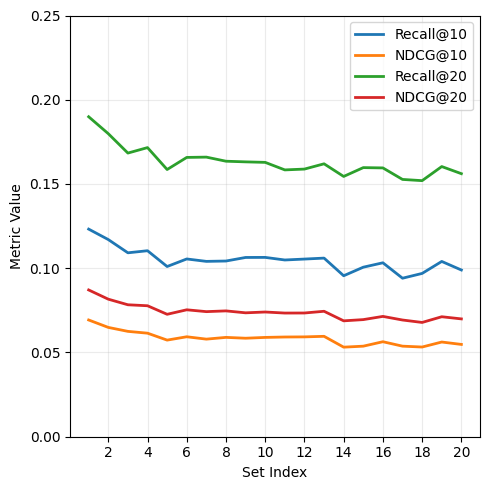

In [28]:
cf_cumulative(num_sets=20, interaction_data="games")

Initial Model Performance (Before Training):
  Recall@10: 0.0045, NDCG@10: 0.0022, Recall@20: 0.0084, NDCG@20: 0.0033
Epoch [   10/200]  Loss: 0.2707  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0884, NDCG@10: 0.0489, Recall@20: 0.1366, NDCG@20: 0.0618
Epoch [   20/200]  Loss: 0.1669  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0986, NDCG@10: 0.0542, Recall@20: 0.1563, NDCG@20: 0.0696
Epoch [   30/200]  Loss: 0.1228  Time: 0.5s Data:0.1s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0995, NDCG@10: 0.0538, Recall@20: 0.1576, NDCG@20: 0.0693
Epoch [   40/200]  Loss: 0.1000  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0966, NDCG@10: 0.0516, Recall@20: 0.1539, NDCG@20: 0.0670
Epoch [   50/200]  Loss: 0.0854  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0948, NDCG@10: 0.0506, Re

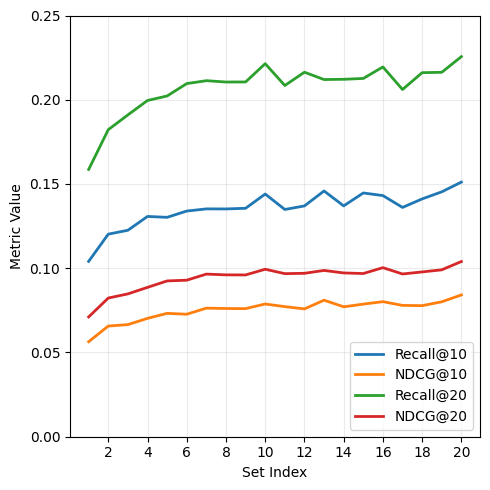

In [29]:
se_cumulative(num_sets=20, interaction_data="games", semantic_data="nvidia")

Initial Model Performance (Before Training):
  Recall@10: 0.0036, NDCG@10: 0.0019, Recall@20: 0.0076, NDCG@20: 0.0030
Epoch [   10/200]  Loss: 0.3080  Time: 0.6s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0524, NDCG@10: 0.0289, Recall@20: 0.0953, NDCG@20: 0.0403
Epoch [   20/200]  Loss: 0.1950  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0623, NDCG@10: 0.0316, Recall@20: 0.1067, NDCG@20: 0.0432
Epoch [   30/200]  Loss: 0.1459  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0599, NDCG@10: 0.0306, Recall@20: 0.1045, NDCG@20: 0.0425
Epoch [   40/200]  Loss: 0.1209  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0589, NDCG@10: 0.0299, Recall@20: 0.1002, NDCG@20: 0.0410
Epoch [   50/200]  Loss: 0.1042  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0575, NDCG@10: 0.0298, Re

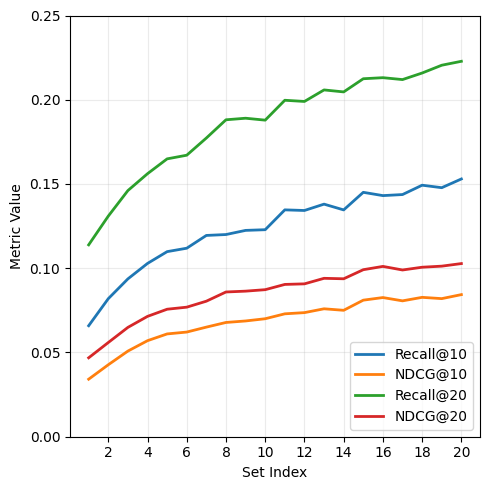

In [30]:
se_cumulative(num_sets=20, interaction_data="games", semantic_data="qwen")

Initial Model Performance (Before Training):
  Recall@10: 0.0052, NDCG@10: 0.0026, Recall@20: 0.0082, NDCG@20: 0.0034
Epoch [   10/200]  Loss: 0.3231  Time: 0.5s Data:0.1s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0649, NDCG@10: 0.0351, Recall@20: 0.1061, NDCG@20: 0.0461
Epoch [   20/200]  Loss: 0.2075  Time: 0.5s Data:0.1s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0719, NDCG@10: 0.0386, Recall@20: 0.1151, NDCG@20: 0.0502
Epoch [   30/200]  Loss: 0.1538  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0733, NDCG@10: 0.0385, Recall@20: 0.1172, NDCG@20: 0.0503
Epoch [   40/200]  Loss: 0.1278  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0728, NDCG@10: 0.0379, Recall@20: 0.1155, NDCG@20: 0.0493
Epoch [   50/200]  Loss: 0.1085  Time: 0.5s Data:0.0s ZG:0.0s Loss:0.2s BW:0.2s Step:0.1s Eval:0.0s Other:0.0s  Recall@10: 0.0699, NDCG@10: 0.0363, Re

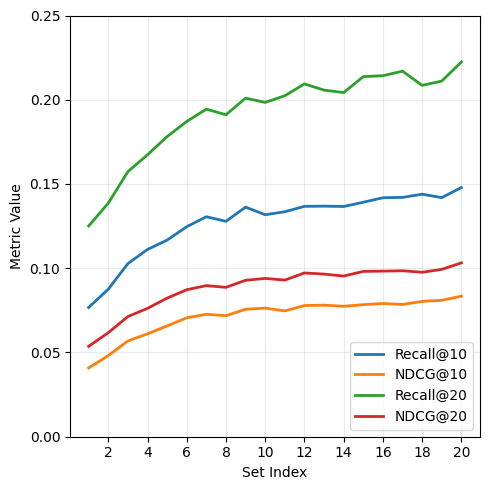

In [31]:
se_cumulative(num_sets=20, interaction_data="games", semantic_data="llama")